In [4]:
import os
import sys
from pathlib import Path

project_root = Path(r"C:\Data\Masai\Practice\Transformer")
sys.path.insert(0, str(project_root))

import torch
import matplotlib.pyplot as plt
from models.bert_for_mlm import BERTForMLM
from tokenizers import Tokenizer

In [8]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

texts = [
    "the king and the queen walked together",
    "he went to the house",
    "it was a good day",
    "the dog chased the cat",
    "the sun rose in the east"
]

tokenIDs_saveFile=r'\training\temp_tokenIDs.pt'
tokenizerJSON_file=r'\tokenizer\artifacts\tokenizer.json'
modelChekpoint_file=r'\training\checkpoints\best_model.pt'

tokenizer= Tokenizer.from_file( str(project_root) + tokenizerJSON_file)
vocabSize = tokenizer.get_vocab_size()
model = BERTForMLM(vocabSize=vocabSize)
checkpoint = torch.load(str(project_root) + modelChekpoint_file)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

tokens=[]
att_matrices=[]
for text in texts:
    encoding = tokenizer.encode(text)
    tokens.append(encoding.tokens)
    inputIDs = torch.tensor([encoding.ids],dtype=torch.long).to(device)

    with torch.no_grad():
        logits, temp_att_matrices = model(inputIDs)
    
    att_matrices.append(temp_att_matrices)

In [13]:
att_matrices[0].shape, att_matrices[1].shape

(torch.Size([1, 6, 8, 7, 7]), torch.Size([1, 6, 8, 5, 5]))

In [19]:
def plot_att_matrices(att, batch_Item, layer, head):
    att = att.cpu().numpy()
    plt.figure(figsize=(8,6))
    plt.imshow(att)
    plt.xticks(range(len(tokens[batch_Item])),tokens[batch_Item],rotation=45)
    plt.yticks(range(len(tokens[batch_Item])),tokens[batch_Item])
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.title(f"batch Item :{batch_Item}, Layer {layer+1} Head {head+1}")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(f"attention_B{batch_Item+1}_L{layer+1}_H{head+1}.png",dpi=300,bbox_inches="tight")
    plt.show()

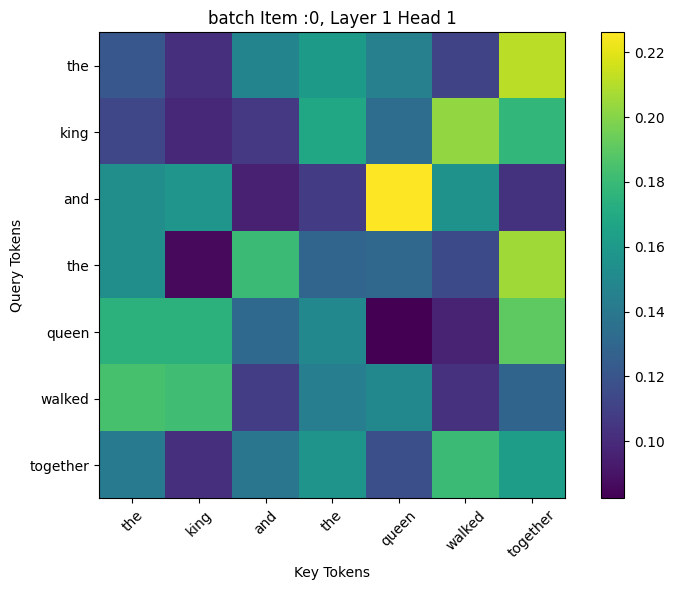

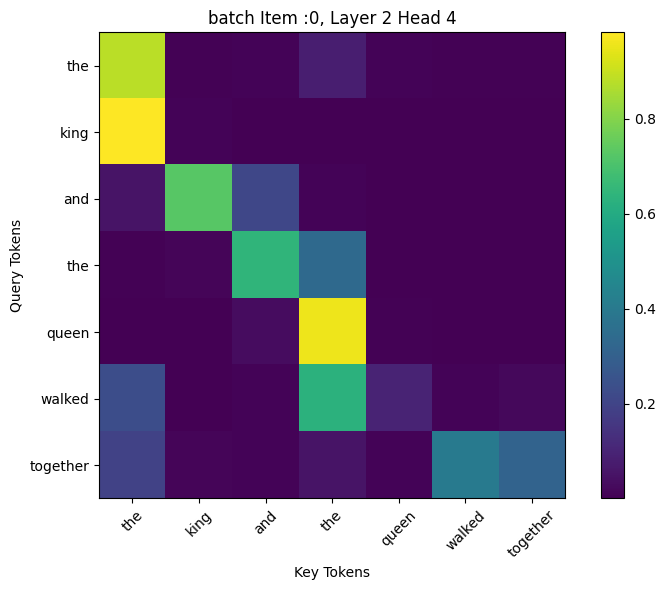

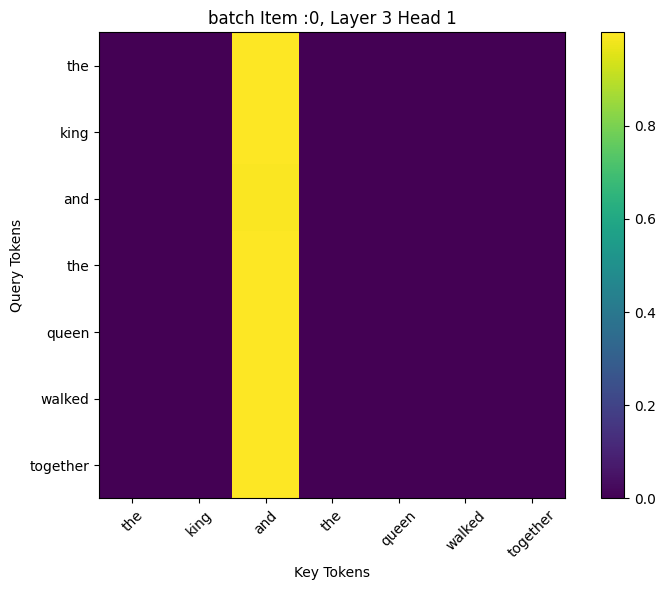

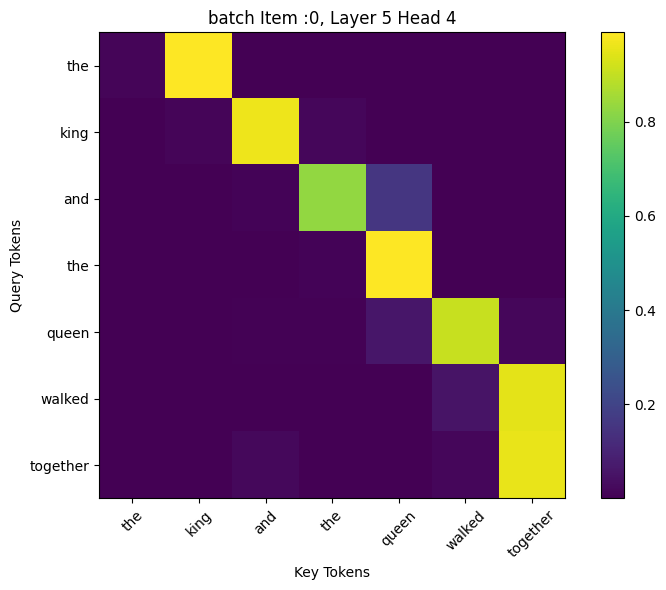

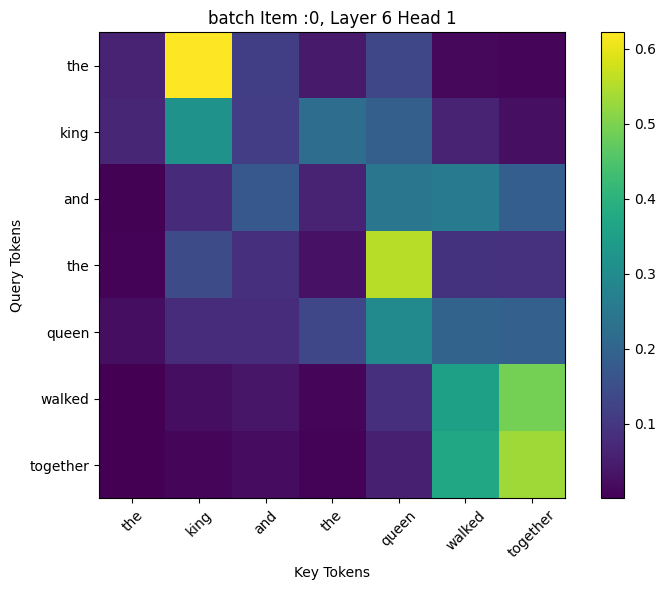

In [21]:
plots = [
    (0, 0, 0),  # Sentence 1, Layer 1 Head 1
    (0, 1, 3),  # Sentence 1, Layer 2 Head 4
    (0, 2, 0),  # Sentence 1, Layer 3 Head 1
    (0, 4, 3),  # Sentence 1, Layer 5 Head 4
    (0, 5, 0),  # Sentence 1, Layer 6 Head 1
]

for batchItem, layer, head in plots:
    plot_att_matrices(att_matrices[batchItem][0,layer, head], batchItem, layer, head)